In [124]:
import os
os.listdir()


['.config', 'multi_item_model.pkl', 'drive', 'retail_sales.csv', 'sample_data']

In [125]:
import os
print(os.listdir("/content"))

['.config', 'multi_item_model.pkl', 'drive', 'retail_sales.csv', 'sample_data']


In [126]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [127]:
import os
print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'add', 'vidhi0.ipynb', 'Screenshot_2023-08-28-12-39-19-95.jpg', 'vidhiminiproject (1).docx', 'vidhiminiproject.docx', 'Copy of AWS_Undertaking_Form (1).docx', 'Copy of AWS_Undertaking_Form.docx', 'Copy of AWS_Undertaking_Form.docx.pdf', '76_VidhiSrivastava.pdf', 'what is difference between preemtive and non pree....gsheet', 'SIH PPT', 'ResumeVidhi', 'eBPF Syscall Rate Limiter (Final Complete Code)', 'Vidhi_Resume.pdf', 'ResumeV1 (2).pdf', 'ResumeV1 (1).pdf', 'ResumeV1.pdf', 'resume.pdf', 'resume (6).pdf', 'Resumee.pdf', 'resume (5).pdf', 'SE Assignment 1 VS.pdf', 'SE Assignment 2 VS.pdf', 'ResumePOL.pdf', 'ResumePON.pdf', 'retail_sales.csv', 'ResumeWPO.pdf']


In [128]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/retail_sales.csv")
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
2,2019-01-03,store_1,item_1,39,21.30,0,3,1
3,2019-01-04,store_1,item_1,35,21.30,0,4,1
4,2019-01-05,store_1,item_1,51,17.04,1,5,1


In [129]:
import os
print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'add', 'vidhi0.ipynb', 'Screenshot_2023-08-28-12-39-19-95.jpg', 'vidhiminiproject (1).docx', 'vidhiminiproject.docx', 'Copy of AWS_Undertaking_Form (1).docx', 'Copy of AWS_Undertaking_Form.docx', 'Copy of AWS_Undertaking_Form.docx.pdf', '76_VidhiSrivastava.pdf', 'what is difference between preemtive and non pree....gsheet', 'SIH PPT', 'ResumeVidhi', 'eBPF Syscall Rate Limiter (Final Complete Code)', 'Vidhi_Resume.pdf', 'ResumeV1 (2).pdf', 'ResumeV1 (1).pdf', 'ResumeV1.pdf', 'resume.pdf', 'resume (6).pdf', 'Resumee.pdf', 'resume (5).pdf', 'SE Assignment 1 VS.pdf', 'SE Assignment 2 VS.pdf', 'ResumePOL.pdf', 'ResumePON.pdf', 'retail_sales.csv', 'ResumeWPO.pdf']


In [130]:
import os
print(os.listdir('/content/sample_data'))

['anscombe.json', 'README.md', 'california_housing_test.csv', 'mnist_train_small.csv', 'california_housing_train.csv', 'mnist_test.csv']


In [131]:
import os
os.listdir('/content/sample_data')

['anscombe.json',
 'README.md',
 'california_housing_test.csv',
 'mnist_train_small.csv',
 'california_housing_train.csv',
 'mnist_test.csv']

In [132]:
print(df.shape)
print(df.columns)
df.info()

(4565000, 8)
Index(['date', 'store_id', 'item_id', 'sales', 'price', 'promo', 'weekday',
       'month'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4565000 entries, 0 to 4564999
Data columns (total 8 columns):
 #   Column    Dtype  
---  ------    -----  
 0   date      object 
 1   store_id  object 
 2   item_id   object 
 3   sales     int64  
 4   price     float64
 5   promo     int64  
 6   weekday   int64  
 7   month     int64  
dtypes: float64(1), int64(4), object(3)
memory usage: 278.6+ MB


In [133]:
df = df[df['store_id'] == 'store_1']

In [134]:
df = df[df['item_id'].isin(['item_1', 'item_2', 'item_3'])]

In [135]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

In [136]:
df.head()

,date,store_id,item_id,sales,price,promo,weekday,month
0,2019-01-01,store_1,item_1,41,21.30,0,1,1
3652,2019-01-01,store_1,item_3,37,82.60,0,1,1
1826,2019-01-01,store_1,item_2,56,30.84,1,1,1
1,2019-01-02,store_1,item_1,53,21.30,0,2,1
3653,2019-01-02,store_1,item_3,40,82.60,0,2,1


In [137]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [138]:
from sklearn.ensemble import RandomForestRegressor

models = {}

for item in df['item_id'].unique():
    item_data = df[df['item_id'] == item]

    X = item_data[['price', 'promo', 'weekday', 'month']]
    y = item_data['sales']

    split = int(len(item_data) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = RandomForestRegressor(n_estimators=50)
    model.fit(X_train, y_train)

    models[item] = model

print("Models trained for items:", list(models.keys()))

Models trained for items: ['item_1', 'item_3', 'item_2']


In [139]:
models = {}

for item in df['item_id'].unique():
    item_data = df[df['item_id'] == item]

    X = item_data[['price', 'promo', 'weekday', 'month']]
    y = item_data['sales']

    model = RandomForestRegressor()
    model.fit(X, y)

    models[item] = model   # 🔥 THIS LINE IS CRITICAL

In [140]:
# To understand what store_ids and item_ids are available in the dataset
# Re-load df to get the original data before filtering
df_original = pd.read_csv('/content/drive/MyDrive/retail_sales.csv')

print("Unique Store IDs:", df_original['store_id'].unique())
print("Unique Item IDs (first 10):", df_original['item_id'].unique()[:10])
print("Total unique Item IDs:", df_original['item_id'].nunique())

Unique Store IDs: ['store_1' 'store_2' 'store_3' 'store_4' 'store_5' 'store_6' 'store_7'
 'store_8' 'store_9' 'store_10' 'store_11' 'store_12' 'store_13'
 'store_14' 'store_15' 'store_16' 'store_17' 'store_18' 'store_19'
 'store_20' 'store_21' 'store_22' 'store_23' 'store_24' 'store_25'
 'store_26' 'store_27' 'store_28' 'store_29' 'store_30' 'store_31'
 'store_32' 'store_33' 'store_34' 'store_35' 'store_36' 'store_37'
 'store_38' 'store_39' 'store_40' 'store_41' 'store_42' 'store_43'
 'store_44' 'store_45' 'store_46' 'store_47' 'store_48' 'store_49'
 'store_50']
Unique Item IDs (first 10): ['item_1' 'item_2' 'item_3' 'item_4' 'item_5' 'item_6' 'item_7' 'item_8'
 'item_9' 'item_10']
Total unique Item IDs: 50


In [141]:
# To understand what store_ids and item_ids are available in the dataset
# Re-load df to get the original data before filtering
df_original = pd.read_csv('/content/drive/MyDrive/retail_sales.csv')

print("Unique Store IDs:", df_original['store_id'].unique())
print("Unique Item IDs (first 10):", df_original['item_id'].unique()[:10])
print("Total unique Item IDs:", df_original['item_id'].nunique())

Unique Store IDs: ['store_1' 'store_2' 'store_3' 'store_4' 'store_5' 'store_6' 'store_7'
 'store_8' 'store_9' 'store_10' 'store_11' 'store_12' 'store_13'
 'store_14' 'store_15' 'store_16' 'store_17' 'store_18' 'store_19'
 'store_20' 'store_21' 'store_22' 'store_23' 'store_24' 'store_25'
 'store_26' 'store_27' 'store_28' 'store_29' 'store_30' 'store_31'
 'store_32' 'store_33' 'store_34' 'store_35' 'store_36' 'store_37'
 'store_38' 'store_39' 'store_40' 'store_41' 'store_42' 'store_43'
 'store_44' 'store_45' 'store_46' 'store_47' 'store_48' 'store_49'
 'store_50']
Unique Item IDs (first 10): ['item_1' 'item_2' 'item_3' 'item_4' 'item_5' 'item_6' 'item_7' 'item_8'
 'item_9' 'item_10']
Total unique Item IDs: 50


In [142]:
item = list(models.keys())[0]

sample = [[100, 1, 2, 3]]

prediction = models[item].predict(sample)

print("Predicted Demand:", prediction[0])

Predicted Demand: 78.33174784798106


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [143]:
print(models.keys())

dict_keys(['item_1', 'item_3', 'item_2'])


In [144]:
models = {}

for item in df['item_id'].unique():
    item_data = df[df['item_id'] == item]

    X = item_data[['price', 'promo', 'weekday', 'month']]
    y = item_data['sales']

    model = RandomForestRegressor()
    model.fit(X, y)

    models[item] = model   # VERY IMPORTANT

In [145]:
print(df.shape)

(5478, 8)


In [146]:
print("Unique items:", df['item_id'].unique())

Unique items: ['item_1' 'item_3' 'item_2']


In [147]:
  df = pd.read_csv("retail_sales.csv")

In [148]:
print(df['store_id'].unique()[:10])

['store_1' 'store_2' 'store_3' 'store_4' 'store_5' 'store_6' 'store_7'
 'store_8' 'store_9' 'store_10']


In [149]:
store = df['store_id'].unique()[0]
df = df[df['store_id'] == store]

print("After store filter:", df.shape)

After store filter: (91300, 8)


In [150]:
print(df['item_id'].unique()[:10])

['item_1' 'item_2' 'item_3' 'item_4' 'item_5' 'item_6' 'item_7' 'item_8'
 'item_9' 'item_10']


In [151]:
items = df['item_id'].unique()[:3]

df = df[df['item_id'].isin(items)]

print("After item filter:", df.shape)

After item filter: (5478, 8)


In [152]:
print(df['store_id'].unique()[:5])
print(df['item_id'].unique()[:5])

['store_1']
['item_1' 'item_2' 'item_3']


In [153]:
items = df['item_id'].unique()[:10]

df = df[df['item_id'].isin(items)]

print("Selected items:", items)
print("Shape:", df.shape)

Selected items: ['item_1' 'item_2' 'item_3']
Shape: (5478, 8)


In [154]:
items = df['item_id'].unique()[:10]

df = df[df['item_id'].isin(items)]

print("Selected items:", items)
print("Shape:", df.shape)

Selected items: ['item_1' 'item_2' 'item_3']
Shape: (5478, 8)


In [155]:
df_full = pd.read_csv("retail_sales.csv")
print("Total items:", df_full['item_id'].nunique())

Total items: 50


In [156]:
df_store = df_full[df_full['store_id'] == 'store_1']
print("Items in this store:", df_store['item_id'].nunique())


Items in this store: 50


In [157]:
print(df['store_id'].unique()[:5])
print(df['item_id'].unique()[:5])


['store_1']
['item_1' 'item_2' 'item_3']


In [158]:
df = pd.read_csv("retail_sales.csv")

In [159]:
print("All items:", df['item_id'].nunique())

All items: 50


In [160]:
df = df[df['store_id'] == 'store_1']

print("Items in store:", df['item_id'].nunique())

Items in store: 50


In [161]:
items = df['item_id'].unique()[:10]

df = df[df['item_id'].isin(items)]

print("Final items:", df['item_id'].nunique())

Final items: 10


In [162]:
print(df['item_id'].nunique())

10


In [163]:
from sklearn.ensemble import RandomForestRegressor

models = {}

for item in df['item_id'].unique():
    item_data = df[df['item_id'] == item]

    X = item_data[['price', 'promo', 'weekday', 'month']]
    y = item_data['sales']

    split = int(len(item_data) * 0.8)

    X_train, X_test = X[:split], X[split:]
    y_train, y_test = y[:split], y[split:]

    model = RandomForestRegressor(n_estimators=50)
    model.fit(X_train, y_train)

    models[item] = model

print("Models trained:", len(models))

Models trained: 10


In [164]:
item = list(models.keys())[0]

sample = [[100, 1, 2, 3]]

prediction = models[item].predict(sample)

print(f"{item} prediction:", prediction[0])

item_1 prediction: 78.36708700714489


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [165]:
import pandas as pd

sample = pd.DataFrame({
    'price': [100],
    'promo': [1],
    'weekday': [2],
    'month': [3]
})

prediction = models[item].predict(sample)

print(f"{item} prediction:", prediction[0])

item_1 prediction: 78.36708700714489


In [166]:
stock = 60

if 76.78 > stock:
    print("Restock Required 🚨")

Restock Required 🚨


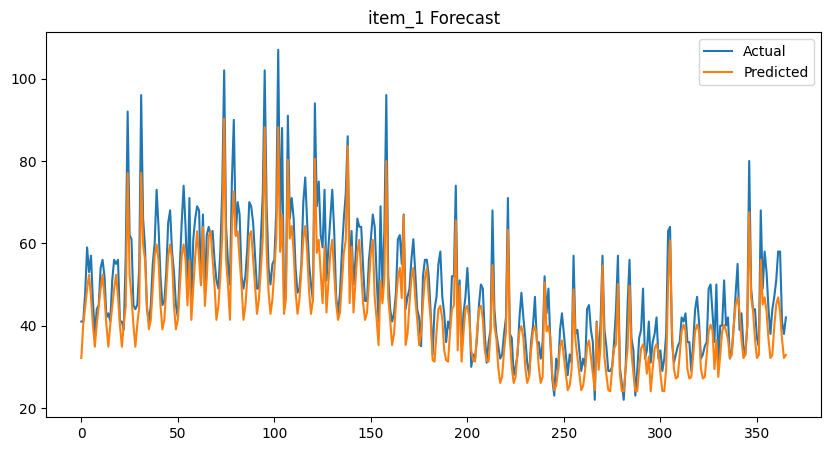

In [167]:
import matplotlib.pyplot as plt

item = list(models.keys())[0]
item_data = df[df['item_id'] == item]

X = item_data[['price', 'promo', 'weekday', 'month']]
y = item_data['sales']

split = int(len(item_data)*0.8)

y_test = y[split:]
y_pred = models[item].predict(X[split:])

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title(f"{item} Forecast")
plt.show()

In [168]:
df['lag_1'] = df.groupby('item_id')['sales'].shift(1)
df['lag_7'] = df.groupby('item_id')['sales'].shift(7)

df = df.dropna()

In [169]:
df['rolling_mean'] = df.groupby('item_id')['sales'].rolling(7).mean().reset_index(0, drop=True)

In [170]:
import joblib
joblib.dump(models, "multi_item_model.pkl")

from google.colab import files
files.download("multi_item_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [171]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)


MAE: 6.007711817099198
RMSE: 7.172564676429664
R2 Score: 0.7620266190313125


In [172]:
stock = 100

y_true = []
y_pred_label = []

for i in range(len(y_test)):
    if y_test.iloc[i] > stock:
        y_true.append("Understock")
    else:
        y_true.append("Overstock")

    if y_pred[i] > stock:
        y_pred_label.append("Understock")
    else:
        y_pred_label.append("Overstock")

In [173]:
print("Actual:", y_test.iloc[0])
print("Predicted:", y_pred[0])
print("Stock Status:", y_pred_label[0])

Actual: 41
Predicted: 32.13383689037963
Stock Status: Overstock


In [174]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_true, y_pred_label)

print("Stock Accuracy:", accuracy)

Stock Accuracy: 0.9918032786885246
